In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def load_plet_data(filepath):
    from nexusformat.nexus import nxload
    
    data = nxload(str(filepath))
    entry_name = list(data.keys())[0]
    entry = data[entry_name]
    
    return entry

filepath = Path("/Users/shubhamshinde/Documents/Neutron Project /Data /benzene_260_360_inc.nxspe")
nxspe_entry = load_plet_data(filepath)

In [3]:
intensity = nxspe_entry['data/data'].nxvalue
energy_edges = nxspe_entry['data/energy'].nxvalue
energy = 0.5 * (energy_edges[:-1] + energy_edges[1:])

print(f"Data shape: {intensity.shape}")
print(f"Energy range: {energy[0]:.2f} to {energy[-1]:.2f} meV")

Data shape: (249, 320)
Energy range: -2.87 to 2.87 meV


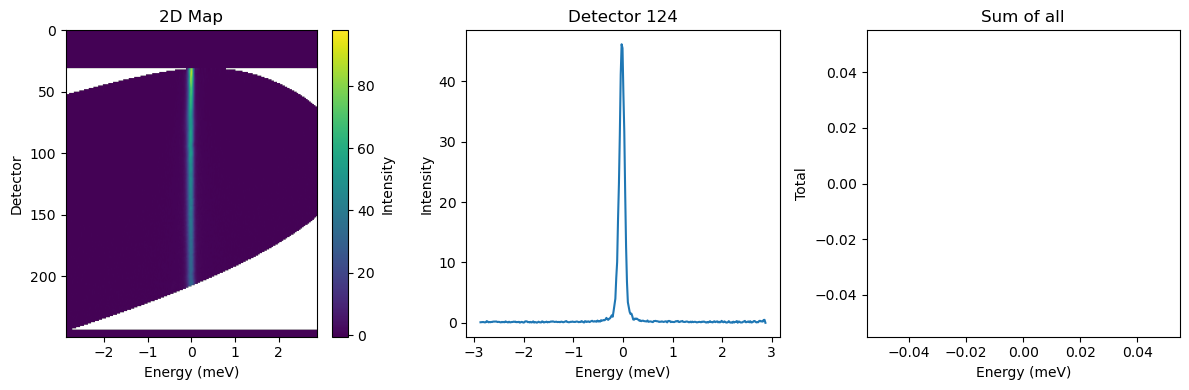

In [4]:
if intensity.shape[0] == len(energy):
    intensity = intensity.T



plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(intensity, aspect='auto', 
           extent=[energy.min(), energy.max(), intensity.shape[0], 0],
           cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Energy (meV)')
plt.ylabel('Detector')
plt.title('2D Map')





plt.subplot(1, 3, 2)
mid_idx = intensity.shape[0] // 2
plt.plot(energy, intensity[mid_idx, :])
plt.xlabel('Energy (meV)')
plt.ylabel('Intensity')
plt.title(f'Detector {mid_idx}')




plt.subplot(1, 3, 3)
total = np.sum(intensity, axis=0)
plt.plot(energy, total)
plt.xlabel('Energy (meV)')
plt.ylabel('Total')
plt.title('Sum of all')



plt.tight_layout()
plt.show()

In [5]:
zero_idx = np.argmin(np.abs(energy))
elastic = intensity[:, zero_idx]

print(f"Total counts: {np.sum(intensity):.0f}")
print(f"Mean: {np.mean(intensity):.2f}")
print(f"Max: {np.max(intensity):.1f}")
print(f"Elastic fraction: {np.sum(elastic)/np.sum(intensity)*100:.1f}%")
print(f"Energy step: {energy[1]-energy[0]:.4f} meV")

Total counts: nan
Mean: nan
Max: nan
Elastic fraction: nan%
Energy step: 0.0180 meV


/var/folders/qx/4fpd5mln61bcz8xrf8x5wjch0000gn/T/ipykernel_1953/4224996532.py:21: RuntimeWarning: invalid value encountered in divide
  spec = intensity[idx, :] / np.max(intensity[idx, :])


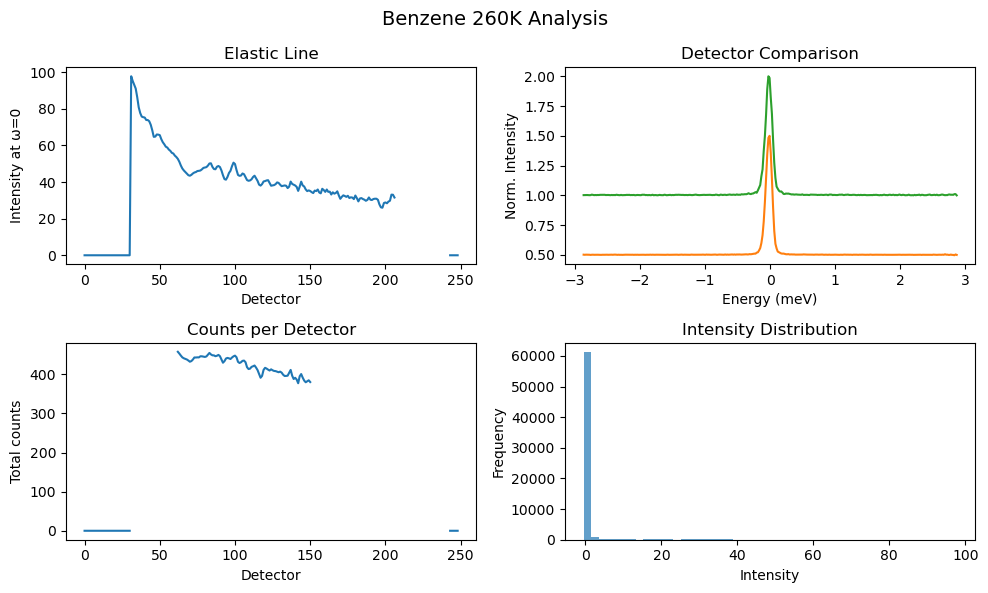

In [6]:
plt.figure(figsize=(10, 6))




# Plot 1: Elastic line
plt.subplot(2, 2, 1)
plt.plot(range(len(elastic)), elastic)
plt.xlabel('Detector')
plt.ylabel('Intensity at ω=0')
plt.title('Elastic Line')





# Plot 2: Multiple detectors
plt.subplot(2, 2, 2)
det_indices = [0, intensity.shape[0]//4, intensity.shape[0]//2, 3*intensity.shape[0]//4]
for i, idx in enumerate(det_indices):
    spec = intensity[idx, :] / np.max(intensity[idx, :])
    plt.plot(energy, spec + i*0.5, label=f'Det {idx}')
plt.xlabel('Energy (meV)')
plt.ylabel('Norm. Intensity')
plt.title('Detector Comparison')





# Plot 3: Integrated per detector
plt.subplot(2, 2, 3)
integrated = np.sum(intensity, axis=1)
plt.plot(range(len(integrated)), integrated)
plt.xlabel('Detector')
plt.ylabel('Total counts')
plt.title('Counts per Detector')





# Plot 4: Energy histogram
plt.subplot(2, 2, 4)
plt.hist(intensity.flatten(), bins=50, alpha=0.7)
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.title('Intensity Distribution')

plt.suptitle('Benzene 260K Analysis', fontsize=14)
plt.tight_layout()
plt.show()

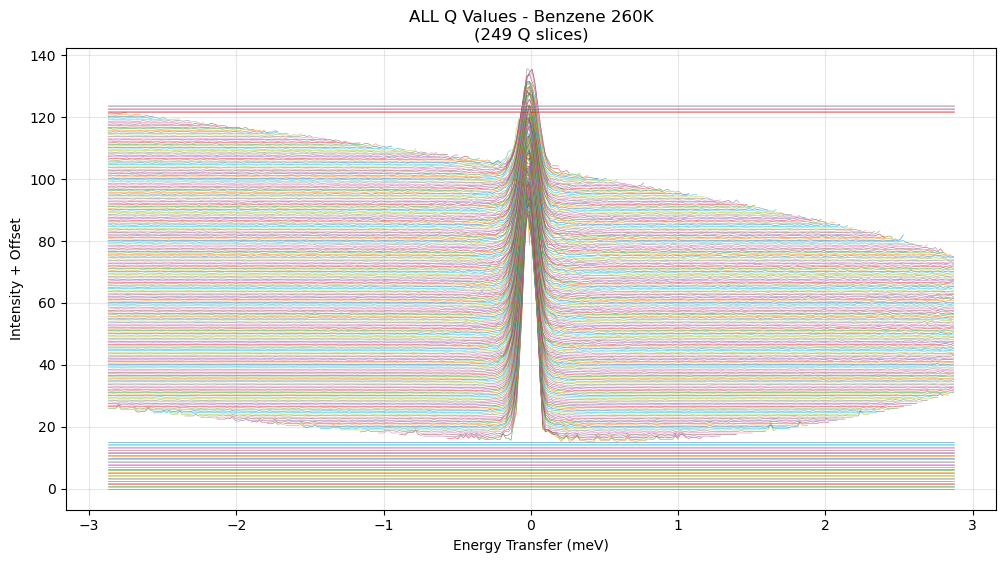

In [7]:
plt.figure(figsize=(12, 6))

for i in range(intensity.shape[0]):
    plt.plot(energy, intensity[i, :] + i*0.5, linewidth=0.5, alpha=0.7)

plt.xlabel('Energy Transfer (meV)')
plt.ylabel('Intensity + Offset')
plt.title(f'ALL Q Values - Benzene 260K\n({intensity.shape[0]} Q slices)')
plt.grid(True, alpha=0.3)
plt.show()

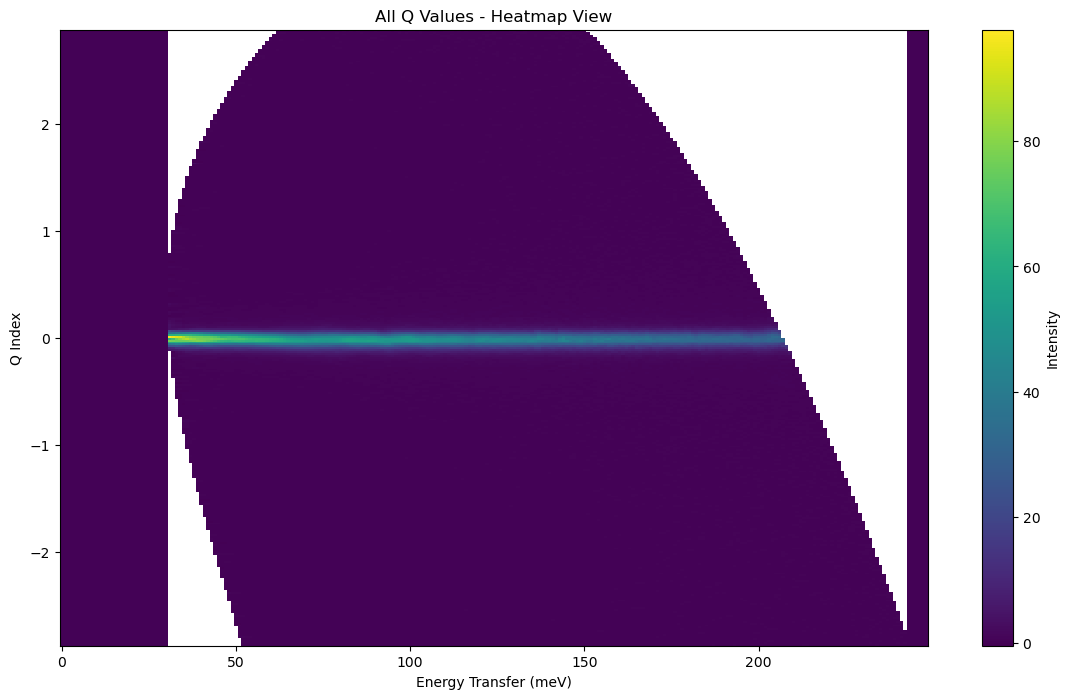

In [8]:
plt.figure(figsize=(14, 8))


Q_indices = np.arange(intensity.shape[0])
Q_grid, E_grid = np.meshgrid(energy, Q_indices, indexing='ij')

plt.pcolormesh(E_grid, Q_grid, intensity.T, shading='auto', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Energy Transfer (meV)')
plt.ylabel('Q Index')
plt.title('All Q Values - Heatmap View')
plt.show()

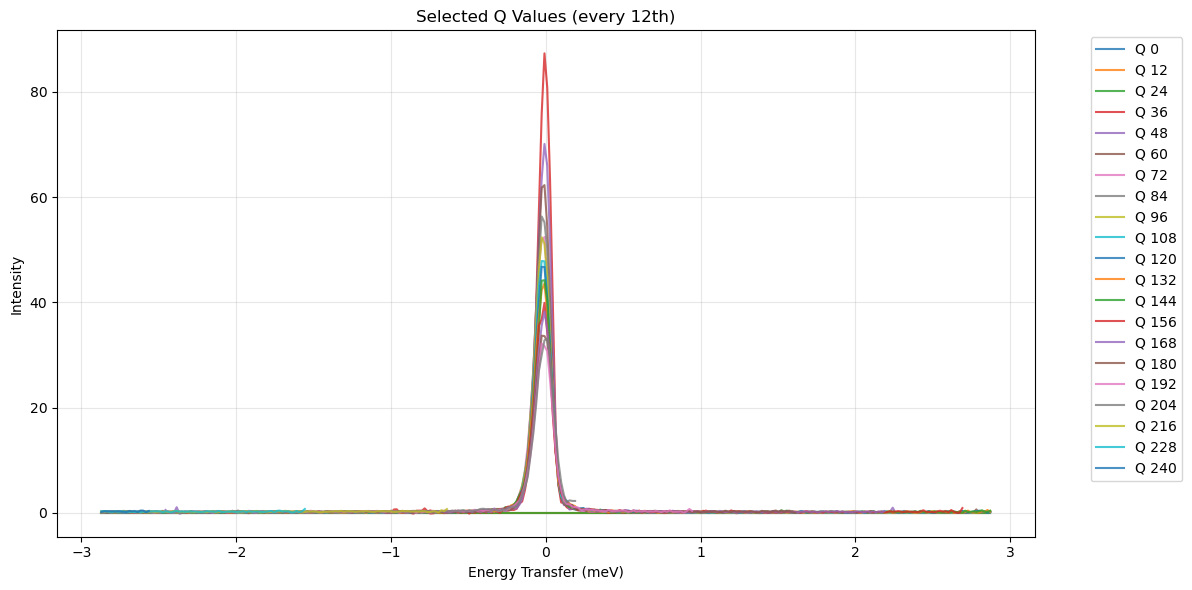

Showing 21 out of 249 Q values


In [9]:
plt.figure(figsize=(12, 6))

step = max(1, intensity.shape[0] // 20)  
q_indices = range(0, intensity.shape[0], step)

for i in q_indices:
    plt.plot(energy, intensity[i, :], linewidth=1.5, alpha=0.8, label=f'Q {i}')

plt.xlabel('Energy Transfer (meV)')
plt.ylabel('Intensity')
plt.title(f'Selected Q Values (every {step}th)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Showing {len(q_indices)} out of {intensity.shape[0]} Q values")

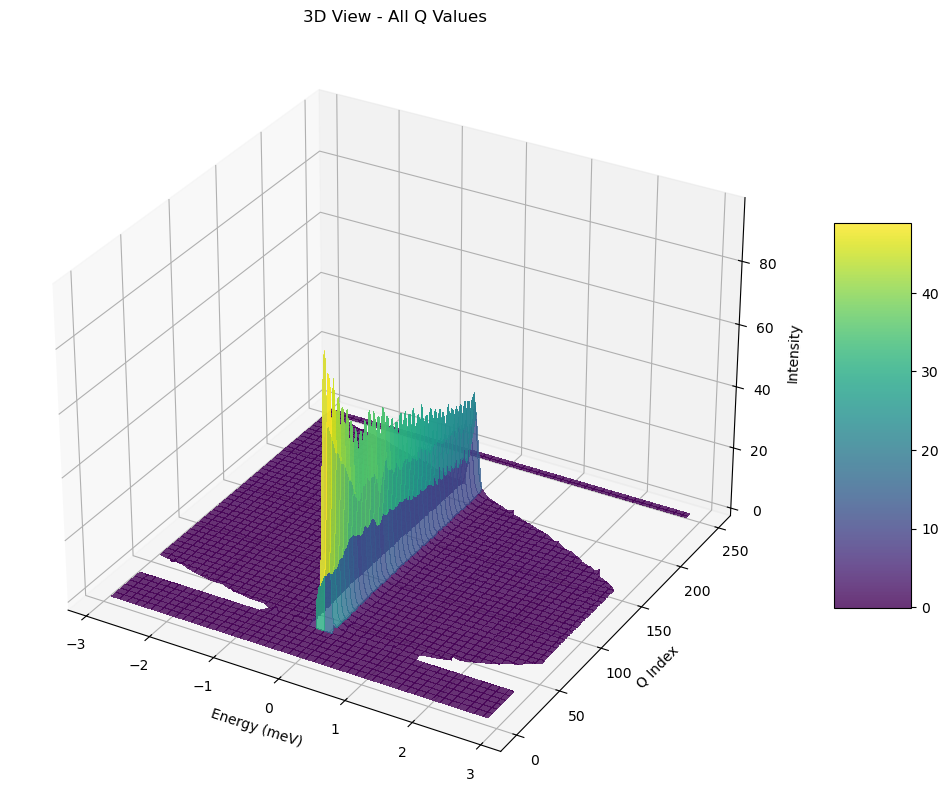

In [10]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')


X, Y = np.meshgrid(energy, np.arange(intensity.shape[0]))


surf = ax.plot_surface(X, Y, intensity, cmap='viridis', 
                      linewidth=0, antialiased=False, alpha=0.8)

ax.set_xlabel('Energy (meV)')
ax.set_ylabel('Q Index')
ax.set_zlabel('Intensity')
ax.set_title('3D View - All Q Values')
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

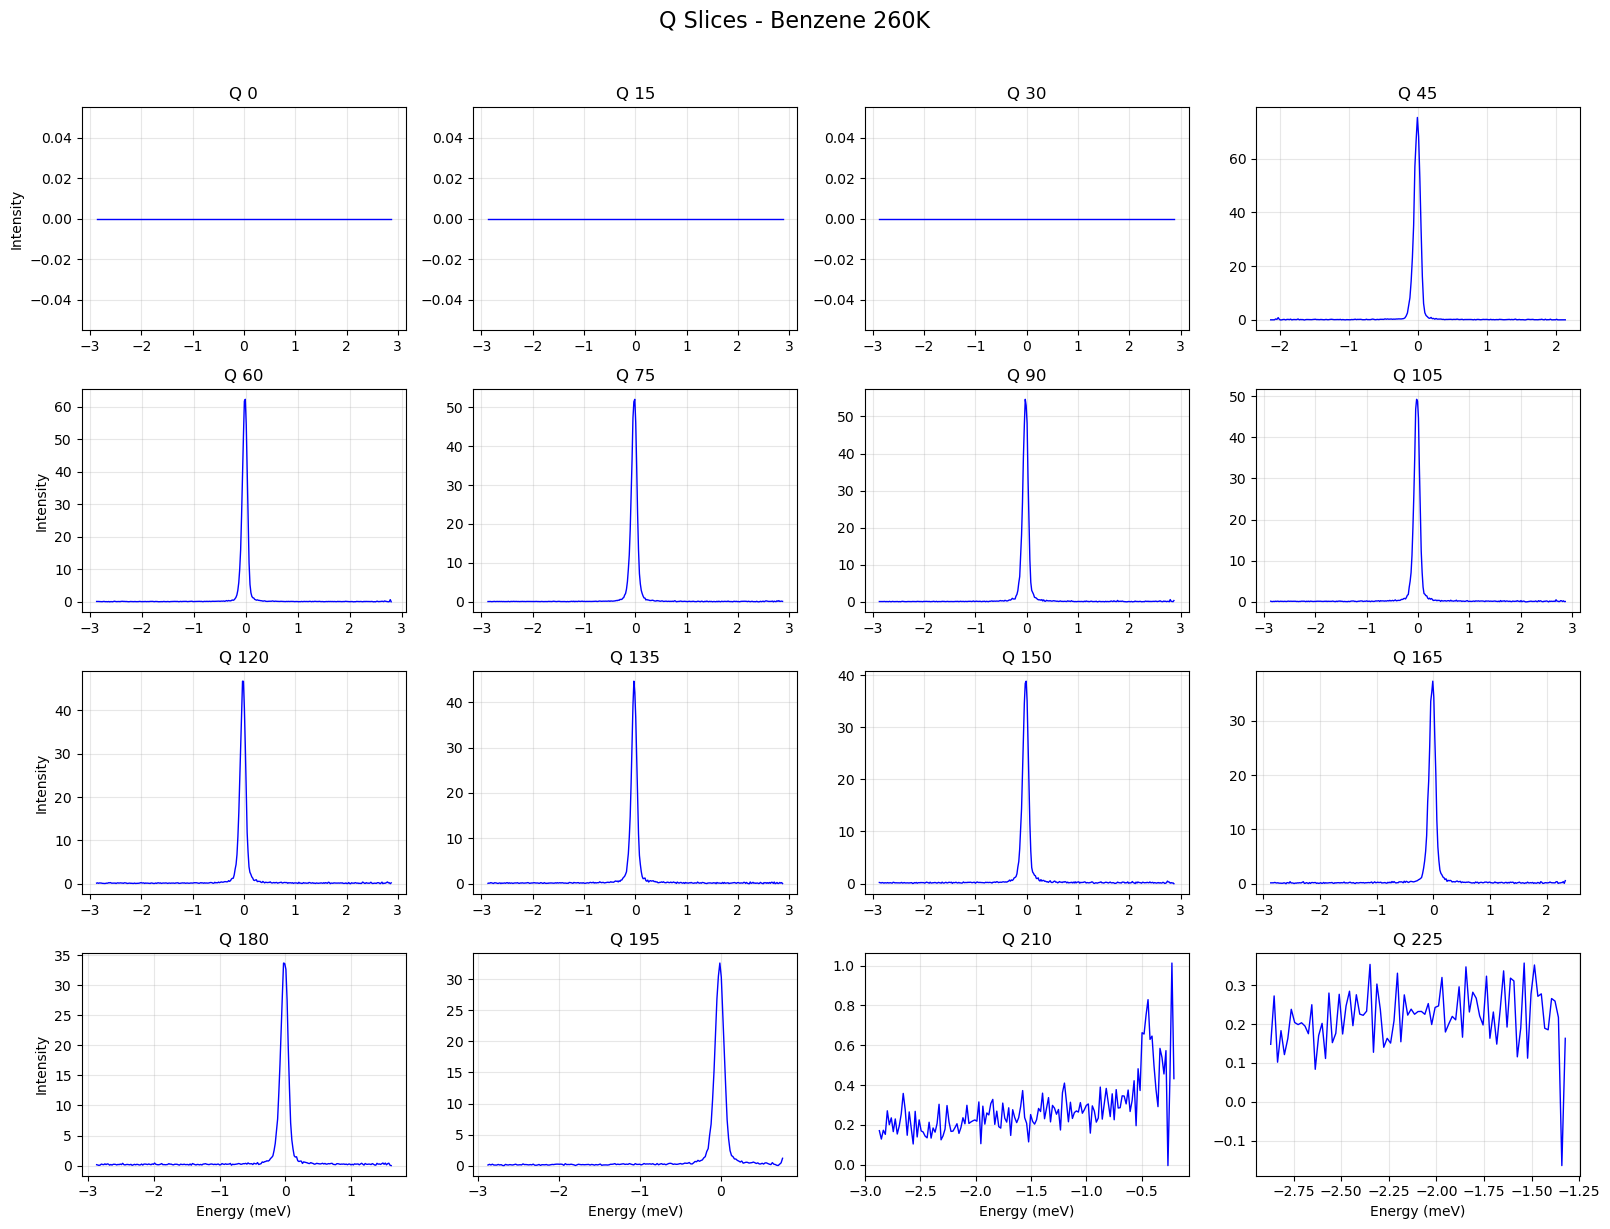

In [11]:
plt.figure(figsize=(16, 12))

n_rows = 4
n_cols = 4
total_plots = n_rows * n_cols
step = max(1, intensity.shape[0] // total_plots)

plot_idx = 0
for row in range(n_rows):
    for col in range(n_cols):
        plt.subplot(n_rows, n_cols, plot_idx + 1)
        
        q_idx = plot_idx * step
        if q_idx < intensity.shape[0]:
            plt.plot(energy, intensity[q_idx, :], 'b-', linewidth=1)
            plt.title(f'Q {q_idx}')
            plt.grid(True, alpha=0.3)
            
            if row == n_rows - 1:
                plt.xlabel('Energy (meV)')
            if col == 0:
                plt.ylabel('Intensity')
        
        plot_idx += 1

plt.suptitle('Q Slices - Benzene 260K', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
try:
    from ipywidgets import interact, IntSlider
    
    def plot_q_slice(q_index):
        plt.figure(figsize=(10, 6))
        plt.plot(energy, intensity[q_index, :], 'b-', linewidth=2)
        plt.fill_between(energy, 0, intensity[q_index, :], alpha=0.3)
        plt.xlabel('Energy Transfer (meV)')
        plt.ylabel('Intensity')
        plt.title(f'Q Slice {q_index}')
        plt.grid(True, alpha=0.3)
        
  
        stats_text = f"Max: {np.max(intensity[q_index, :]):.1f}\n"
        stats_text += f"Sum: {np.sum(intensity[q_index, :]):.0f}\n"
        stats_text += f"Mean: {np.mean(intensity[q_index, :]):.2f}"
        
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.show()
    
    interact(plot_q_slice, 
             q_index=IntSlider(min=0, max=intensity.shape[0]-1, 
                              step=1, value=intensity.shape[0]//2,
                              description='Q Index:'))
    
except ImportError:
    print("install ipywidgets")

interactive(children=(IntSlider(value=124, description='Q Index:', max=248), Output()), _dom_classes=('widget-…

In [13]:
# save_plots = input("Save all Q plots? (y/n): ")

# if save_plots.lower() == 'y':
#     import os
#     os.makedirs('q_plots', exist_ok=True)
    
#     for q_idx in range(intensity.shape[0]):
#         plt.figure(figsize=(8, 5))
#         plt.plot(energy, intensity[q_idx, :], 'b-', linewidth=1.5)
#         plt.xlabel('Energy Transfer (meV)')
#         plt.ylabel('Intensity')
#         plt.title(f'Benzene 260K - Q Slice {q_idx}')
#         plt.grid(True, alpha=0.3)
        
#         plt.savefig(f'q_plots/q_slice_{q_idx:03d}.png', dpi=100, bbox_inches='tight')
#         plt.close()
    
#     print(f"Saved {intensity.shape[0]} Q plots to 'q_plots' folder")